# Initialize

In [125]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import matplotlib.pyplot as plt
import time
import numpy as np

LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
# Get ArtemisBLEController object
ble = get_ble_controller()

# Connect to the Artemis Device
ble.connect()
ble.reload_config()

2026-04-09 18:37:04,605 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:42:0c:78:b8:49
2026-04-09 18:37:04,607 | INFO     |: Scanning for device with address: c0:42:0c:78:b8:49, service UUID: d427e7cc-c400-4597-b417-d564e20d6600
2026-04-09 18:37:14,657 | INFO     |: Found 1 device(s) advertising service d427e7cc-c400-4597-b417-d564e20d6600
2026-04-09 18:37:14,659 | INFO     |: Selecting device: 3AE32BFA-4071-EC2D-ED7A-60CCA92DBE18 (name: Artemis BLE)
2026-04-09 18:37:15,631 | INFO     |: Connected to c0:42:0c:78:b8:49


In [157]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_2_values = []
orient_setpoint_values = []
orient_sensor_values = []
orient_output_values = []


def log_handler(sender, data: bytearray):
    parts = ble.bytearray_to_string(data).split("|")
    if len(parts) == 11:
        t = float(parts[0][2:])
        l = float(parts[1][5:])
        r = float(parts[2][5:])
        ax = float(parts[3][3:])
        ay = float(parts[4][3:])
        gz = float(parts[5][3:])
        yw = float(parts[6][3:])
        t2 = float(parts[7][3:])
        os = float(parts[8][3:])
        ov = float(parts[9][3:])
        oo = float(parts[10][3:])

        times.append(t) # Convert microseconds to seconds
        left_motors.append(l)
        right_motors.append(r)
        acc_x_values.append(ax)
        acc_y_values.append(ay)
        gyr_z_values.append(gz)
        yaw_values.append(yw)
        tof_2_values.append(t2)
        orient_setpoint_values.append(os)
        orient_output_values.append(ov)
        orient_sensor_values.append(oo)


        print (f"t: {t:.2f}, lm: {l:.2f}, rm: {r:.2f}, ax: {ax:.2f}, ay: {ay:.2f}, gz: {gz:.2f}, yw: {yw:.2f}, t2: {t2:.2f}, os: {os:.2f}, ov: {ov:.2f}, oo: {oo:.2f}")
    else:
        print(ble.bytearray_to_string(data))

In [158]:
ble.start_notify(ble.uuid["RX_STRING"], log_handler)

# Control

In [174]:
ble.send_command(CMD.SET_MODE, "5")
ble.send_command(CMD.SET_DURATION, "60000")
ble.send_command(CMD.SET_MOTOR_SCALE, "1.0")

# ble.send_command(CMD.SET_ORIENT_SETPOINT, "0")
ble.send_command(CMD.SET_MAP_DEGREES, "720")
ble.send_command(CMD.UPDATE_ORIENT_PID, "2.5|1.2|0.25")
ble.send_command(CMD.SET_SAMPLE_RATE, "50")

In [175]:
times = []
left_motors = []
right_motors = []
acc_x_values = []
acc_y_values = []
gyr_z_values = []
yaw_values = []
tof_2_values = []
orient_setpoint_values = []
orient_sensor_values = []
orient_output_values = []

ble.send_command(CMD.START_RECORD, "")
time.sleep(60)
ble.send_command(CMD.SEND_LOG, "")

t: 21.00, lm: 0.00, rm: 0.00, ax: -11.47, ay: -10.01, gz: -0.12, yw: 28.14, t2: -1.00, os: 720.00, ov: 0.00, oo: 0.00
t: 59.00, lm: 101.00, rm: -151.00, ax: -118.41, ay: 39.79, gz: 0.36, yw: 28.15, t2: -1.00, os: 20.00, ov: 0.01, oo: -50.91
t: 95.00, lm: 102.00, rm: -152.00, ax: -188.72, ay: -156.00, gz: -7.44, yw: 28.29, t2: -1.00, os: 20.00, ov: 0.14, oo: -51.01
t: 122.00, lm: 101.00, rm: -151.00, ax: -491.21, ay: -81.30, gz: 15.61, yw: 28.52, t2: -1.00, os: 20.00, ov: 0.38, oo: -50.82
t: 143.00, lm: 103.00, rm: -152.00, ax: -125.98, ay: -151.85, gz: -0.55, yw: 28.52, t2: -1.00, os: 20.00, ov: 0.38, oo: -51.34
t: 171.00, lm: 106.00, rm: -154.00, ax: 21.48, ay: 55.66, gz: -8.96, yw: 28.54, t2: -1.00, os: 20.00, ov: 0.40, oo: -52.31
t: 193.00, lm: 106.00, rm: -154.00, ax: -191.89, ay: -385.50, gz: 6.58, yw: 28.65, t2: -1.00, os: 20.00, ov: 0.51, oo: -52.33
t: 215.00, lm: 105.00, rm: -154.00, ax: 501.95, ay: 202.39, gz: 4.02, yw: 28.72, t2: -1.00, os: 20.00, ov: 0.58, oo: -52.15
t: 252.

In [177]:
times = np.array(times)
left_motors = np.array(left_motors)
right_motors = np.array(right_motors)
acc_x_values = np.array(acc_x_values)
acc_y_values = np.array(acc_y_values)
gyr_z_values = np.array(gyr_z_values)
yaw_values = np.array(yaw_values)
tof_2_values = np.array(tof_2_values)
orient_setpoint_values = np.array(orient_setpoint_values)
orient_sensor_values = np.array(orient_sensor_values)
orient_output_values = np.array(orient_output_values)


In [178]:
np.savez("lab9/control_720_1TOF_2.npz", 
    times=times, 
    left_motors=left_motors, 
    right_motors=right_motors, 
    acc_x_values=acc_x_values, 
    acc_y_values=acc_y_values, 
    gyr_z_values=gyr_z_values, 
    yaw_values=yaw_values,
    tof_2_values=tof_2_values, 
    orient_setpoint_values=orient_setpoint_values, 
    orient_sensor_values=orient_sensor_values, 
    orient_output_values=orient_output_values
)

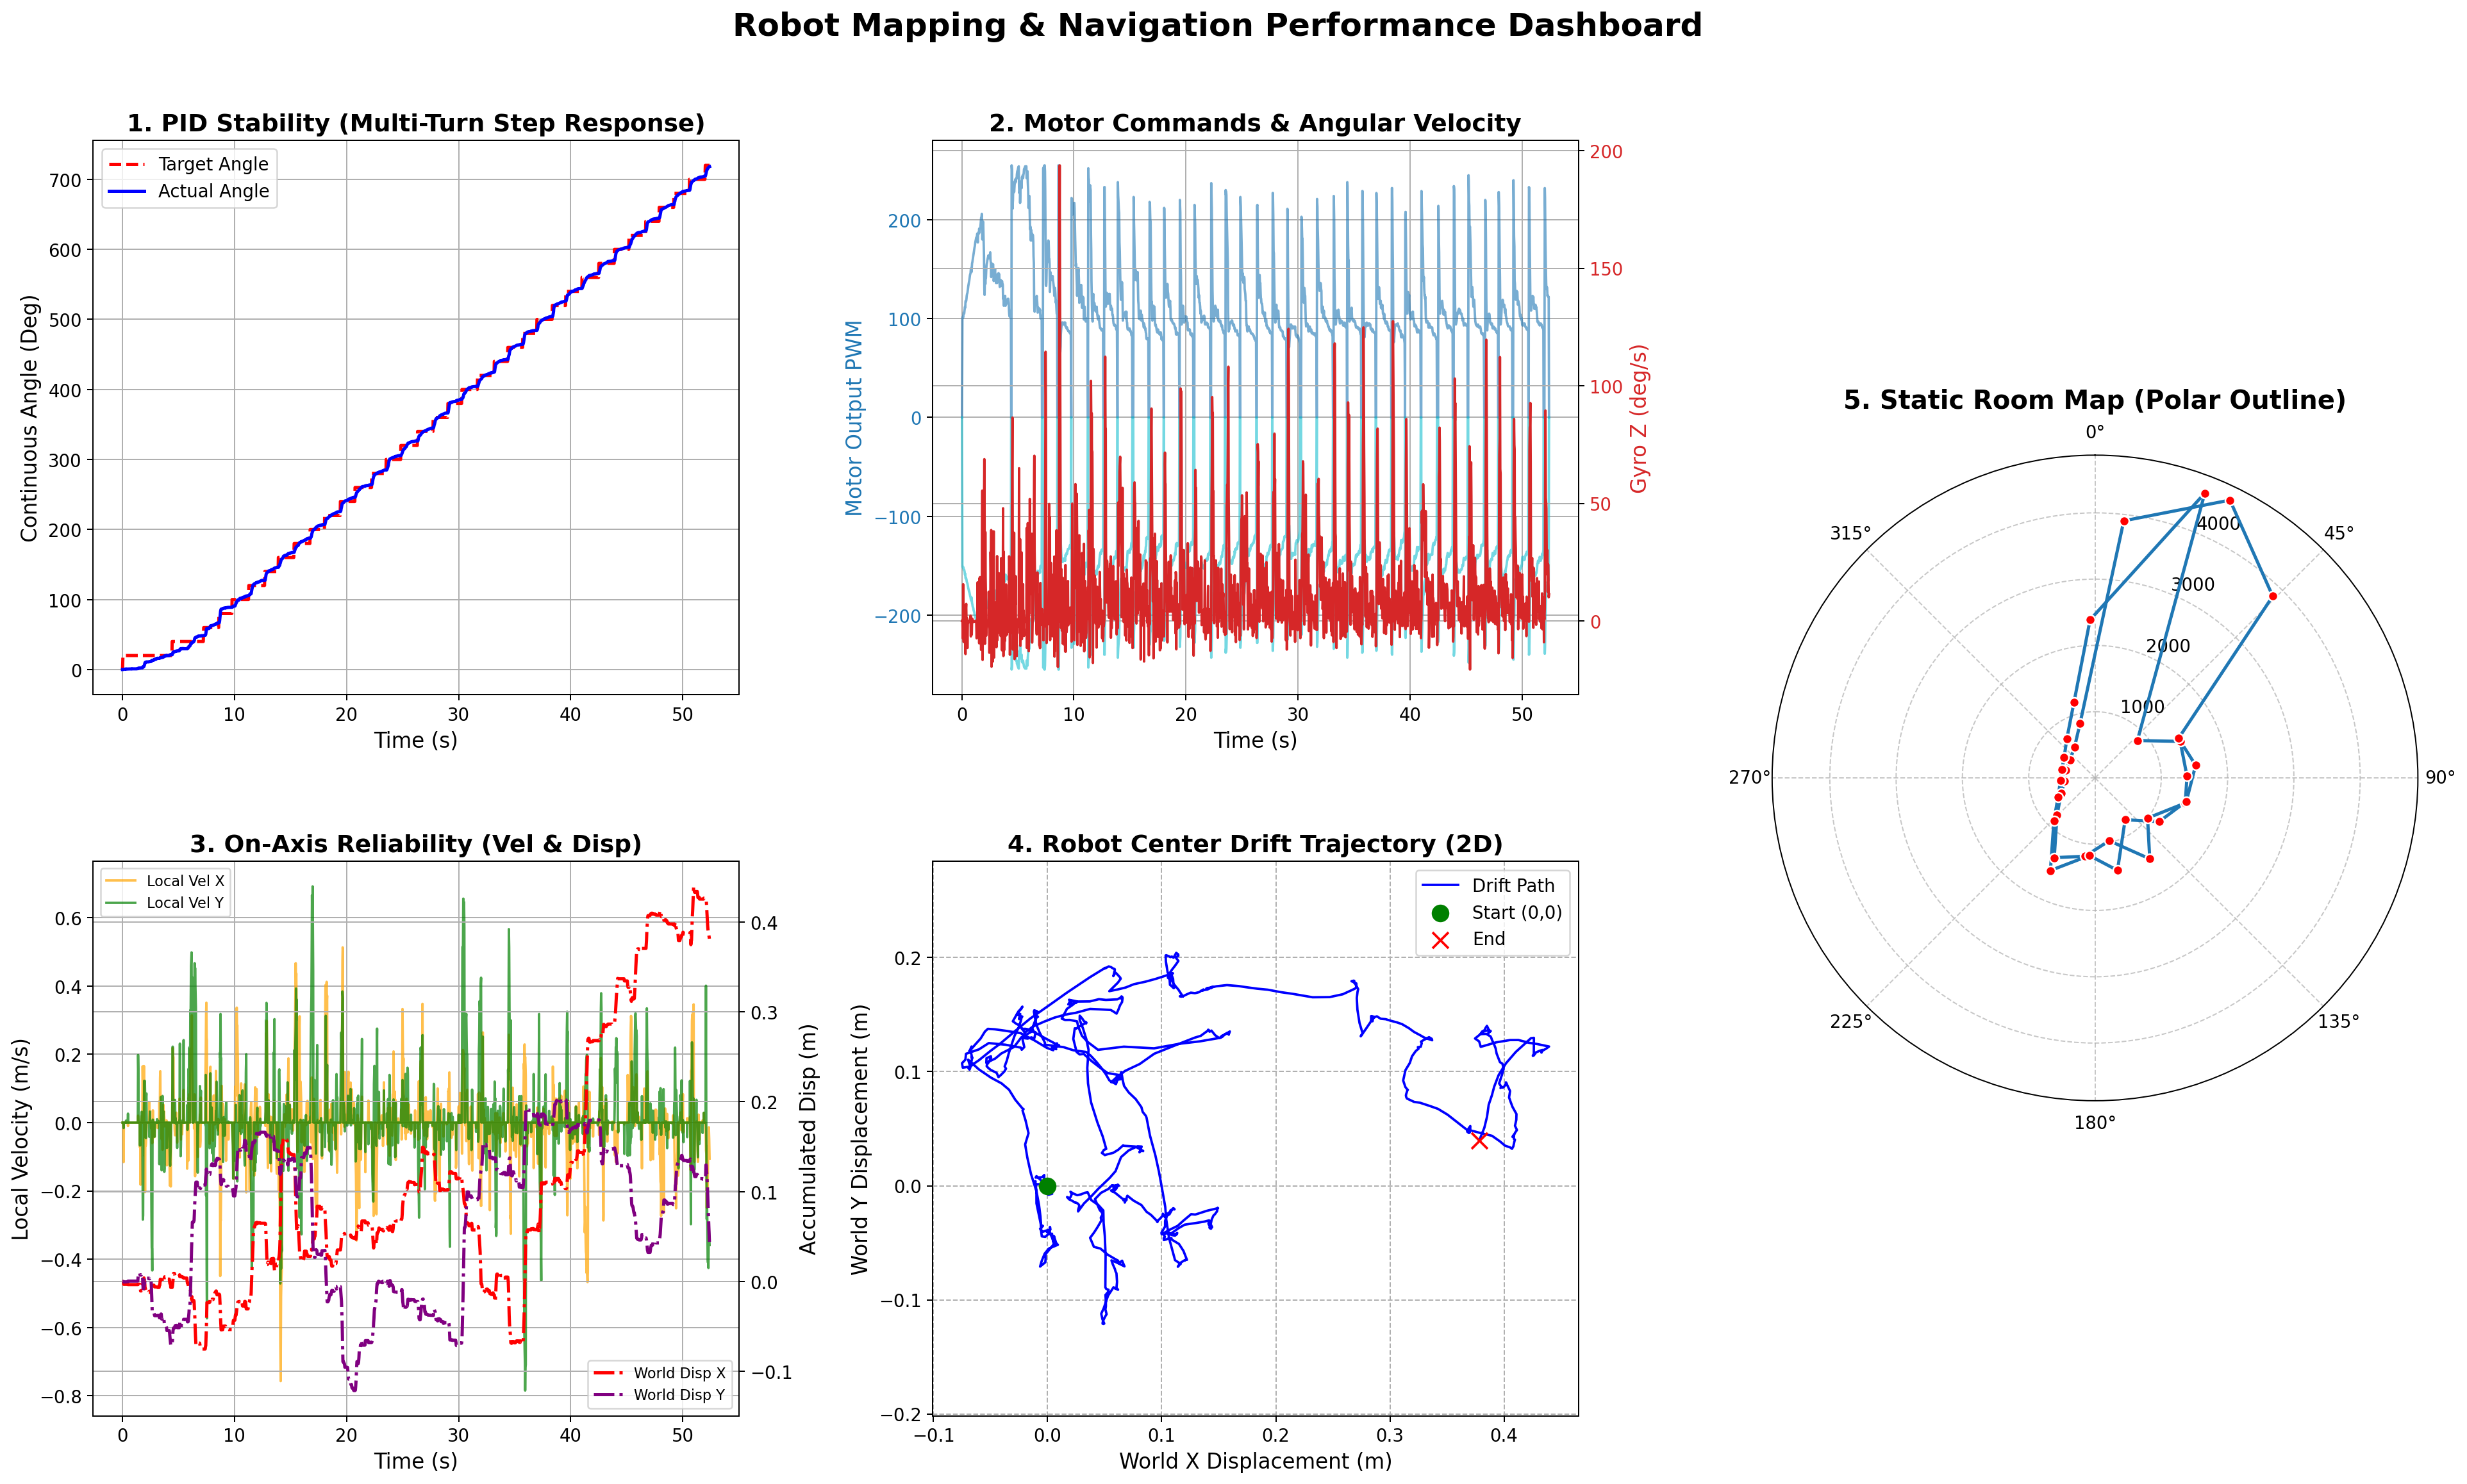

=== Mapping Summary ===
Total valid points: 36
Max line of sight:  4660.00 mm
Closest wall dist:  452.00 mm

=== Drift Summary ===
Final X Drift:      378.35 mm
Final Y Drift:      39.82 mm
Total Center Shift: 380.43 mm


In [185]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ==========================================
# 1. 修复角度数据：将 Wrapped Yaw 解包为 Continuous Yaw
# ==========================================
times_sec = times / 1000.0

yaw_unwrapped = np.degrees(np.unwrap(np.radians(yaw_values)))
yaw_continuous = yaw_unwrapped - yaw_unwrapped[0]
orient_setpoint_continuous = orient_setpoint_values
orient_setpoint_continuous[0] = yaw_continuous[0]

# ==========================================
# 2. 核心计算：加速度 -> 局部速度 -> 世界速度 -> 世界位移
# ==========================================


STOP_THRESHOLD_GYRO = 10.0 
stationary_mask = np.abs(gyr_z_values) < STOP_THRESHOLD_GYRO
acc_x_bias = np.mean(acc_x_values[stationary_mask])
acc_y_bias = np.mean(acc_y_values[stationary_mask])

acc_x_clean = acc_x_values - acc_x_bias
acc_y_clean = acc_y_values - acc_y_bias

velocity_world_x = np.zeros_like(acc_x_values, dtype=float)
velocity_world_y = np.zeros_like(acc_y_values, dtype=float)
disp_world_x = np.zeros_like(acc_x_values, dtype=float)
disp_world_y = np.zeros_like(acc_y_values, dtype=float)

ACC_SCALE = 9.81 / 1000.0 *0.9
VELOCITY_DAMPING = 1

for i in range(1, len(times)):
    dt = (times[i] - times[i-1]) / 1000.0
    
    if stationary_mask[i]:
        # 停稳时，世界速度清零 (ZUPT)
        velocity_world_x[i] = 0.0
        velocity_world_y[i] = 0.0
    else:
        # 🌟 关键修正 1：获取当前角度
        # 避坑检查：如果你的陀螺仪是顺时针(右转)角度变大，这里必须加负号：np.radians(-yaw_continuous[i])
        # 如果是逆时针(左转)角度变大，保持原样：np.radians(yaw_continuous[i])
        theta = np.radians(yaw_continuous[i])
        
        # 🌟 关键修正 2：先将 Local 加速度旋转为 World 加速度
        a_world_x = acc_x_clean[i] * np.cos(theta) - acc_y_clean[i] * np.sin(theta)
        a_world_y = acc_x_clean[i] * np.sin(theta) + acc_y_clean[i] * np.cos(theta)
        
        # 🌟 关键修正 3：在 World 坐标系下进行带阻尼的速度积分
        velocity_world_x[i] = velocity_world_x[i-1] * VELOCITY_DAMPING + a_world_x * ACC_SCALE * dt
        velocity_world_y[i] = velocity_world_y[i-1] * VELOCITY_DAMPING + a_world_y * ACC_SCALE * dt
    
    # 🌟 关键修正 4：直接对 World 速度积分得到 World 位移
    disp_world_x[i] = disp_world_x[i-1] + velocity_world_x[i] * dt
    disp_world_y[i] = disp_world_y[i-1] + velocity_world_y[i] * dt


# ==========================================
# 开始绘图
# ==========================================
plt.rcParams['figure.dpi'] = 180      # notebook / 屏幕显示清晰度
plt.rcParams['savefig.dpi'] = 300     # 保存图片清晰度
plt.rcParams['font.size'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11



fig = plt.figure(figsize=(26, 14))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 1], wspace=0.3, hspace=0.3)

# ------------------------------------------
# [1] 左上: PID 角度控制分析
# ------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(times_sec, orient_setpoint_continuous, label='Target Angle', linestyle='--', color='red', linewidth=2)
ax1.plot(times_sec, yaw_continuous, label='Actual Angle', color='blue', linewidth=2)
ax1.set_title('1. PID Stability (Multi-Turn Step Response)', fontweight='bold')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Continuous Angle (Deg)')
ax1.grid(True)
ax1.legend()

# ------------------------------------------
# [2] 中上: 电机输出与角速度响应
# ------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(times_sec, left_motors, label='Left PWM', color='tab:blue', alpha=0.6)
ax2.plot(times_sec, right_motors, label='Right PWM', color='tab:cyan', alpha=0.6)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Motor Output PWM', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True)

ax2_twin = ax2.twinx()
ax2_twin.plot(times_sec, gyr_z_values, label='Gyro Z', color='tab:red', linewidth=1.5)
ax2_twin.set_ylabel('Gyro Z (deg/s)', color='tab:red')
ax2_twin.tick_params(axis='y', labelcolor='tab:red')
ax2.set_title('2. Motor Commands & Angular Velocity', fontweight='bold')

# ------------------------------------------
# [3] 左下: 原地旋转可靠性 (速度与世界位移)
# ------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(times_sec, velocity_x, label='Local Vel X', color='orange', alpha=0.7)
ax3.plot(times_sec, velocity_y, label='Local Vel Y', color='green', alpha=0.7)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Local Velocity (m/s)')
ax3.grid(True)
ax3.legend(loc='upper left', fontsize=9)

ax3_twin = ax3.twinx()
ax3_twin.plot(times_sec, disp_world_x, label='World Disp X', color='red', linestyle='-.', linewidth=2)
ax3_twin.plot(times_sec, disp_world_y, label='World Disp Y', color='purple', linestyle='-.', linewidth=2)
ax3_twin.set_ylabel('Accumulated Disp (m)')
ax3_twin.legend(loc='lower right', fontsize=9)
ax3.set_title('3. On-Axis Reliability (Vel & Disp)', fontweight='bold')

# ------------------------------------------
# [4] 中下: 机器人在地面的 2D 纯漂移轨迹
# ------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(disp_world_x, disp_world_y, label='Drift Path', color='blue')
ax4.scatter(disp_world_x[0], disp_world_y[0], color='green', marker='o', s=100, label='Start (0,0)', zorder=5)
ax4.scatter(disp_world_x[-1], disp_world_y[-1], color='red', marker='x', s=100, label='End', zorder=5)
ax4.set_title('4. Robot Center Drift Trajectory (2D)', fontweight='bold')
ax4.set_xlabel('World X Displacement (m)')
ax4.set_ylabel('World Y Displacement (m)')
ax4.axis('equal') # 保证 X Y 比例一致，圆形不会被拉伸成椭圆
ax4.grid(True, linestyle='--')
ax4.legend()

# ------------------------------------------
# [5] 右侧一整列: 极坐标房间建图 (跨两行)
# ------------------------------------------
valid_indices = (tof_2_values > 0) & (tof_2_values < 6000)
valid_angles_rad = np.radians(yaw_continuous[valid_indices])
valid_distances = tof_2_values[valid_indices]


if len(valid_distances) > 0:
    # gs[:, 2] 意味着占满所有的行，位于第3列
    sorted_indices = np.argsort(valid_angles_rad)
    sorted_angles = valid_angles_rad[sorted_indices]
    sorted_distances = valid_distances[sorted_indices]

    sorted_angles = np.append(sorted_angles, sorted_angles[0])
    sorted_distances = np.append(sorted_distances, sorted_distances[0])

    ax5 = fig.add_subplot(gs[:, 2], projection='polar')
    ax5.plot(sorted_angles, sorted_distances, color='tab:blue', linewidth=2, 
             linestyle='-', marker='o', markersize=6, markerfacecolor='red', markeredgecolor='white')
    
    ax5.set_theta_zero_location('N')
    ax5.set_theta_direction(-1)      
    ax5.set_title('5. Static Room Map (Polar Outline)', va='bottom', fontsize=16, fontweight='bold')
    ax5.grid(True, linestyle='--', alpha=0.7)
else:
    ax5 = fig.add_subplot(gs[:, 2])
    ax5.text(0.5, 0.5, "No Valid ToF Data", ha='center', va='center', fontsize=20)
    ax5.set_title('5. Static Room Map', fontweight='bold')

# 自动调整边距以防止标签重叠
fig.suptitle('Robot Mapping & Navigation Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)
# plt.tight_layout() 与 subplots_adjust 配合，避免 title 和上方重叠
fig.subplots_adjust(top=0.90) 
plt.show()

# ------------------------------------------
# 打印汇总数据报告
# ------------------------------------------
if len(valid_distances) > 0:
    print(f"=== Mapping Summary ===")
    print(f"Total valid points: {len(valid_distances)}")
    print(f"Max line of sight:  {np.max(valid_distances):.2f} mm")
    print(f"Closest wall dist:  {np.min(valid_distances):.2f} mm")
    
    final_drift_x = disp_world_x[-1] * 1000 
    final_drift_y = disp_world_y[-1] * 1000
    total_drift = np.sqrt(final_drift_x**2 + final_drift_y**2)
    print(f"\n=== Drift Summary ===")
    print(f"Final X Drift:      {final_drift_x:.2f} mm")
    print(f"Final Y Drift:      {final_drift_y:.2f} mm")
    print(f"Total Center Shift: {total_drift:.2f} mm")

# Read Out Distance

1. support 2 tof
2. >=2 rotation